In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Data/DataCo.csv")

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Order Zipcode,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,NaN,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,NaN,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,NaN,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,NaN,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,NaN,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 41)

### Total no of rows 180519 and cols 41

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment               180519 non

### There are 9 integer cols,18 object cols and 14 float cols

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077


In [7]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Customer Zipcode                      3
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0
Order City                            0
Order Country                         0
order date (DateOrders)               0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0


###  3 missing valuees were found in the customer zipcode.

In [8]:
df=df.dropna(subset=["Customer Zipcode"])

In [9]:
df=df.drop(columns=["Order Zipcode"])

### i have droped the missing values rows because this is very small portion of the dataset. and i have drop one colm having 155679 missing values

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Id                      0
Customer Segment                 0
Customer State                   0
Customer Zipcode                 0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
order date (DateOrders)          0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales               

### no missing values

### Categorical consistency

In [12]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print("\ncolumn:", col)
    print("Unique values:", df[col].nunique())
    print("\nValue counts:")
    print(df[col].value_counts().head(10))

C:\Users\vartika singh\AppData\Local\Temp\ipykernel_11700\2882463295.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns



column: Type
Unique values: 4

Value counts:
Type
DEBIT       69293
TRANSFER    49883
PAYMENT     41724
CASH        19616
Name: count, dtype: int64

column: Delivery Status
Unique values: 4

Value counts:
Delivery Status
Late delivery        98976
Advance shipping     41592
Shipping on time     32194
Shipping canceled     7754
Name: count, dtype: int64

column: Category Name
Unique values: 50

Value counts:
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Name: count, dtype: int64

column: Customer City
Unique values: 562

Value counts:
Customer City
Caguas          66770
Chicago          3885
Los Angeles      3417
Brooklyn         3412
New York         1816
Philadelphia     1577
Bronx            1500
San Diego        1437
M

### logical checks   

###

In [13]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Profit Per Order,Order Region,Order State,Order Status,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,91.250000,Southeast Asia,Java Occidental,COMPLETE,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,-249.089996,South Asia,Rajastán,PENDING,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,-247.779999,South Asia,Rajastán,CLOSED,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,22.860001,Oceania,Queensland,COMPLETE,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,134.210007,Oceania,Queensland,PENDING_PAYMENT,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [14]:
(df["Days for shipping (real)"] > df["Days for shipment (scheduled)"]).sum()

np.int64(103399)

### In 103,399 orders, the actual shipping time was more than the scheduled time .shows many orders took longer time than expected .

In [15]:
(df["Days for shipping (real)"] < 0).sum()

np.int64(0)

In [16]:
(df["Days for shipment (scheduled)"] < 0).sum()

np.int64(0)

In [17]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

In [18]:
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

### order date and shipping date is converted into datetime format.

In [19]:
print("Shipping date before order date:",(df["shipping date (DateOrders)"] <df["order date (DateOrders)"]).sum())

Shipping date before order date: 0


In [20]:
df.groupby("Category Id")["Category Name"].nunique().max()

np.int64(1)

Each category ID is linked to only one category name,so the category information is consistent.

In [21]:
df.groupby("Product Category Id")["Category Name"].nunique().max()

np.int64(1)

each Product Category Id is linked only to one category name so there is no mismatch btw them.

In [22]:
df.groupby("Order Item Cardprod Id")["Product Name"].nunique().max()

np.int64(1)

each Order Item Cardprod Id(product id) is linked to only one product name,so the category information is consistent.

### outliers

In [23]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Latitude',
       'Longitude', 'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Product Category Id',
       'Product Price', 'Product Status'],
      dtype='str')


In [24]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].skew().sort_values(ascending=False)

Product Price                    3.191093
Order Item Product Price         3.191093
Order Item Discount              3.039940
Order Item Total                 2.888481
Sales per customer               2.888481
Sales                            2.884304
Order Item Quantity              0.880227
Customer Zipcode                 0.490883
Customer Id                      0.488763
Product Category Id              0.361571
Category Id                      0.361571
Order Item Discount Rate         0.340926
Order Item Cardprod Id           0.138238
Days for shipping (real)         0.084770
Product Status                   0.000000
Latitude                        -0.097935
Late_delivery_risk              -0.194089
Longitude                       -0.498496
Days for shipment (scheduled)   -0.731999
Order Item Profit Ratio         -2.893501
Benefit per order               -4.741797
Order Profit Per Order          -4.741797
dtype: float64

In [25]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_count = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()
print(outlier_count)

Days for shipping (real)             0
Days for shipment (scheduled)        0
Benefit per order                18942
Sales per customer                1943
Late_delivery_risk                   0
Category Id                          0
Customer Id                       1197
Customer Zipcode                     0
Latitude                             9
Longitude                         1414
Order Item Cardprod Id               0
Order Item Discount               7537
Order Item Discount Rate             0
Order Item Product Price          2048
Order Item Profit Ratio          17300
Order Item Quantity                  0
Sales                              488
Order Item Total                  1943
Order Profit Per Order           18942
Product Category Id                  0
Product Price                     2048
Product Status                       0
dtype: int64


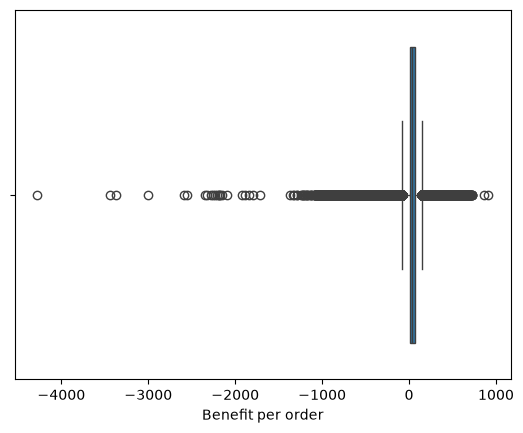

In [26]:
sns.boxplot(x=df["Benefit per order"])
plt.show()

1. Most of the values are concentrated near 0,but the several extreme values are mainly on negative side <br>
2. these values are outliers and they can be high losses.<br>
3.we cannot remove outliers bcoz they can be genuine losses.

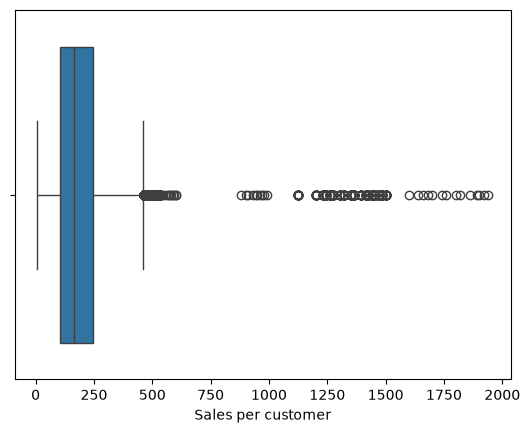

In [27]:
sns.boxplot(x=df["Sales per customer"])
plt.show()

1.Most values are concentrated roughly between 0 and 250.<br>
2.There are potential outliers, with some values reaching around 2000.<br>
3.a small number of customers have much higher sales than most customers.<br>
4.we cannot remove outliers bcoz they can be genuine high  value customers.

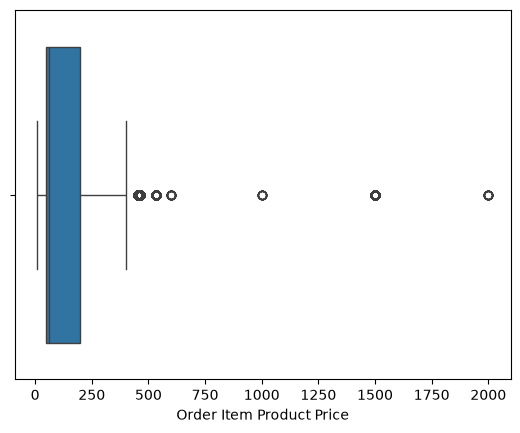

In [28]:
sns.boxplot(x=df["Order Item Product Price"])
plt.show()

1.Most of the product prices are in the lower range.<br>
2.A few products have very high prices.<br>
3.These extreme values are potential outliers.<br>

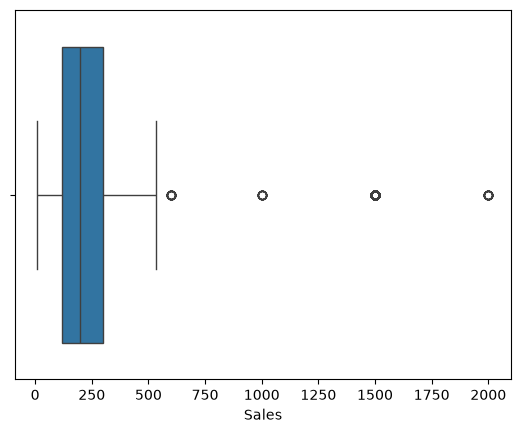

In [29]:
sns.boxplot(x=df["Sales"])
plt.show()

Most sales values are in the lower range.<br>
A few orders have very high sales.<br>
These values are potential outliers.

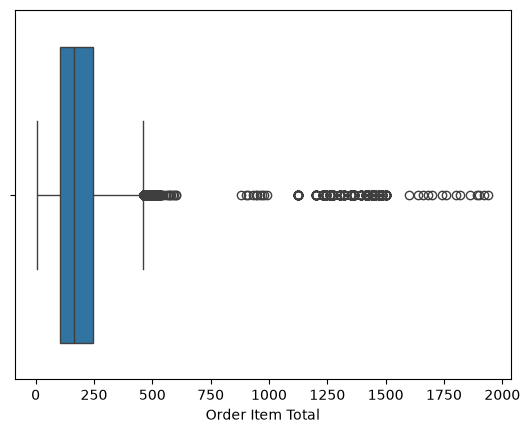

In [30]:
sns.boxplot(x=df["Order Item Total"])
plt.show()

Most order totals are in the lower range.<br>
Some orders have very high total values.<br>
These extreme values are potential outliers.

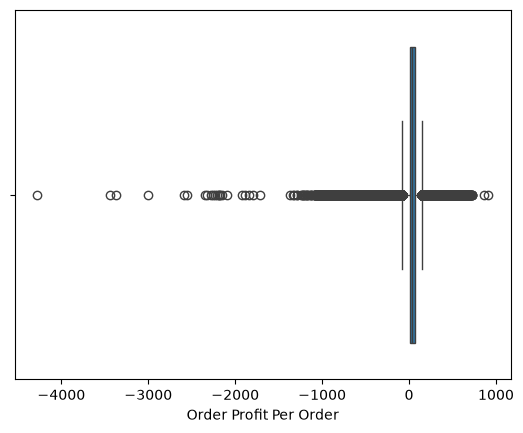

In [31]:
sns.boxplot(x=df["Order Profit Per Order"])
plt.show()

Most profit values are close to 0.<br>
Some orders show very high negative or positive profit.<br>
These extreme values are potential outliers.

### UNIVARIATE ANALYSIS

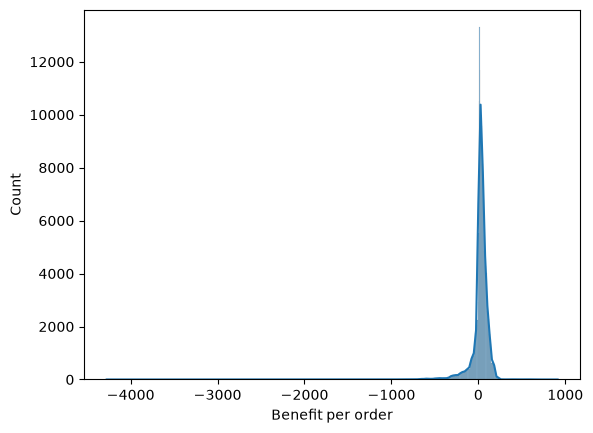

In [32]:
sns.histplot(df["Benefit per order"], kde=True)
plt.show()

Most values are concentrated near 0.<br>
The distribution is left-skewed.<br>
A few extreme values are present on both sides.

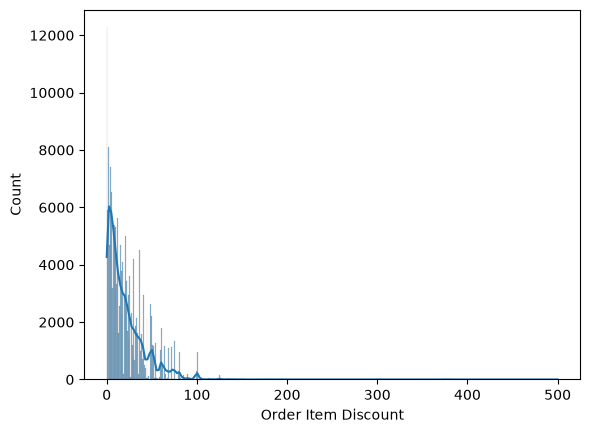

In [33]:
sns.histplot(df["Order Item Discount"], kde=True)
plt.show()

The distribution is right skewed <br>
most of the discount values concentrated at lower range .<br>
A few orders have high discount but that can genuine so that we cannot remove that outliers.

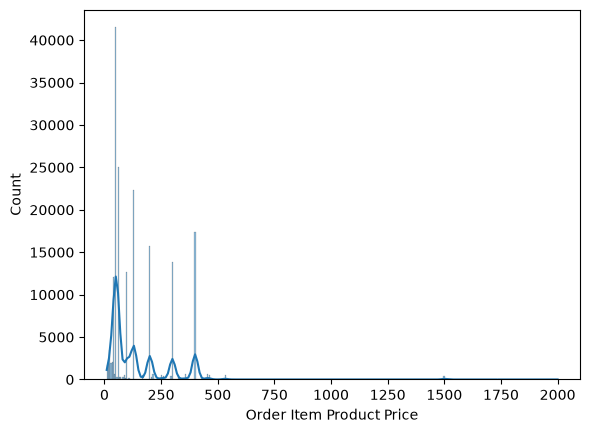

In [34]:
sns.histplot(df["Order Item Product Price"], kde=True)
plt.show()

The distributiion is concentrated at lower product prices.
There are a few products with much higher prices which are outliers

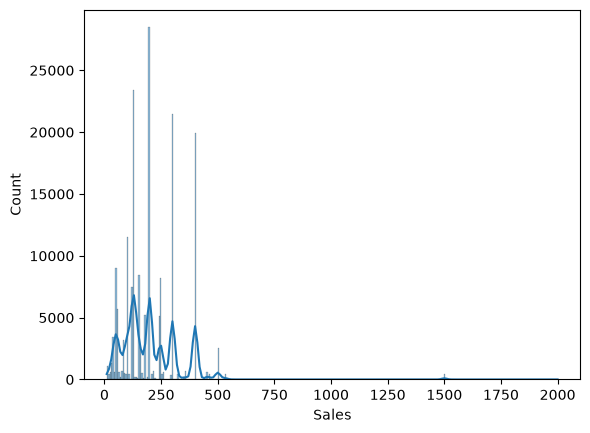

In [35]:
sns.histplot(df["Sales"], kde=True)
plt.show()

The distribution is concentrated in the lower sales range.

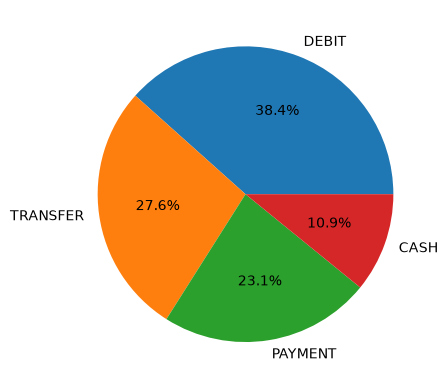

In [36]:
df["Type"].value_counts().plot.pie(autopct="%0.1f%%")
plt.show()

DEBIT transactions are the highest.<br>
TRANSFER is the second highest <br>
CASH transactions are the lowest<br>


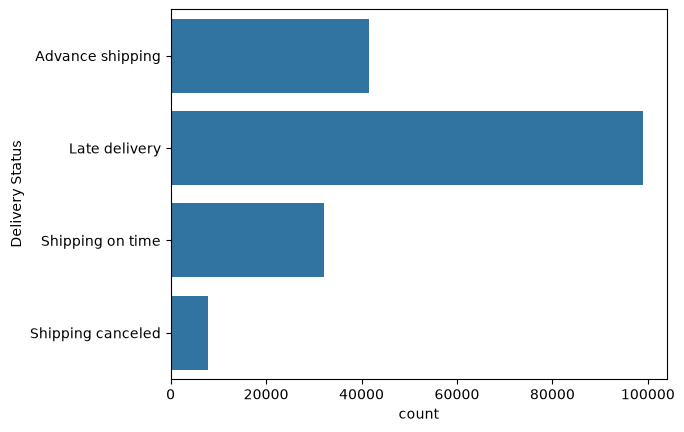

In [37]:
sns.countplot(df["Delivery Status"])
plt.show()


Late delivery has the highest number of orders.<br>
Advance shipping is the second highest.<br>
Shipping canceled has the lowest count.<br>


### BIVARIATE ANALYSIS

<Axes: >

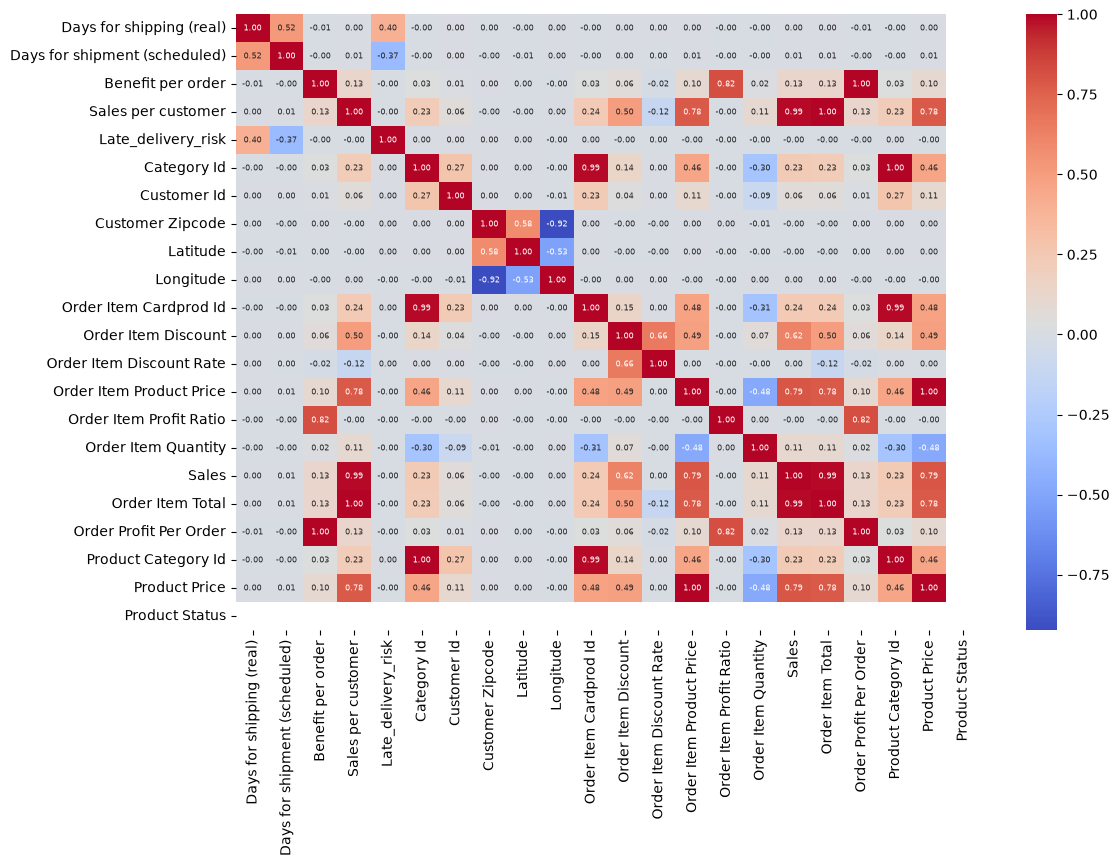

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only = True) , annot =True , fmt = '.2f' , cmap = 'coolwarm' , annot_kws = {'size':6})

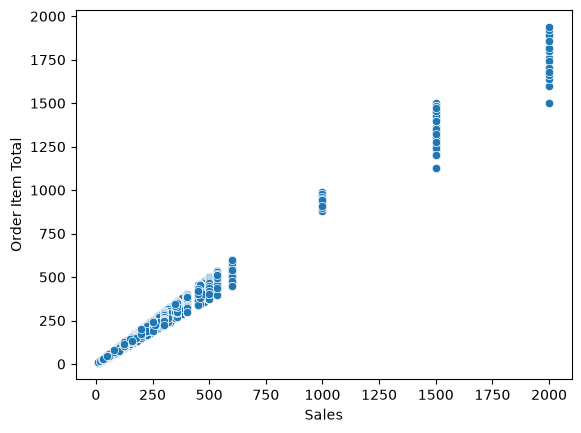

In [39]:
sns.scatterplot(x=df["Sales"], y=df["Order Item Total"])
plt.show()

As sales increses,order item total total also increases<br>
the correlation in heatmap which is positive 0.99

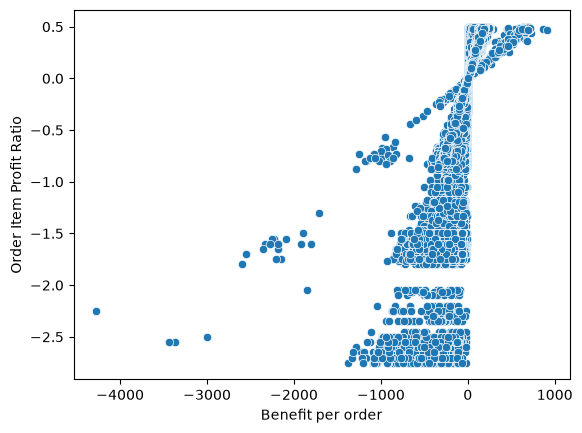

In [40]:
sns.scatterplot(x=df["Benefit per order"], y=df["Order Item Profit Ratio"])
plt.show()

higher benefit values are generally having higher profit ratio<br>
there are some extreme values on negative side

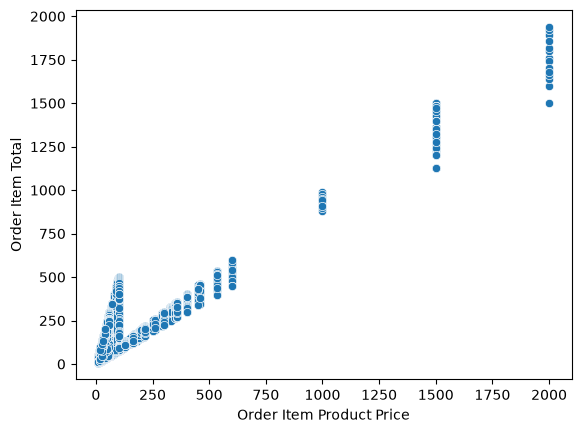

In [41]:
sns.scatterplot(x=df["Order Item Product Price"], y=df["Order Item Total"])
plt.show()

order item product price and order item total show a strong positive relationship.<br>
higher product price generally lead to higher order item total

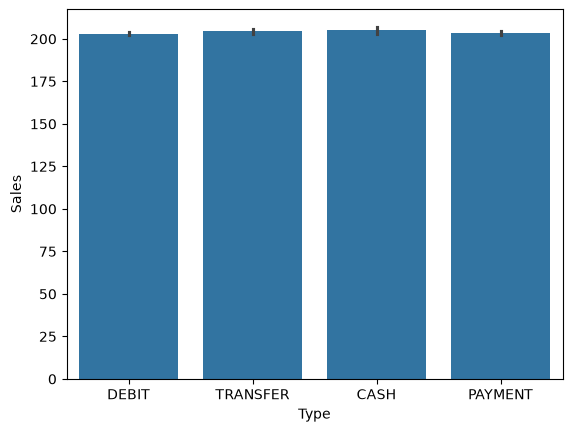

In [42]:
sns.barplot(x=df["Type"],y=df["Sales"])
plt.show()

sales are almost similar across all transaction types

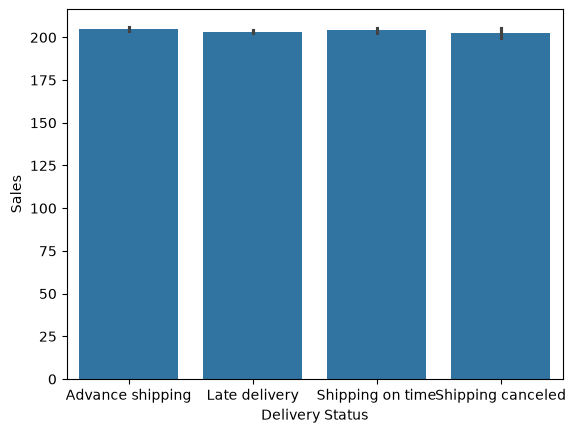

In [43]:
sns.barplot(x=df["Delivery Status"],y=df["Sales"])
plt.show()

### multivariate analysis

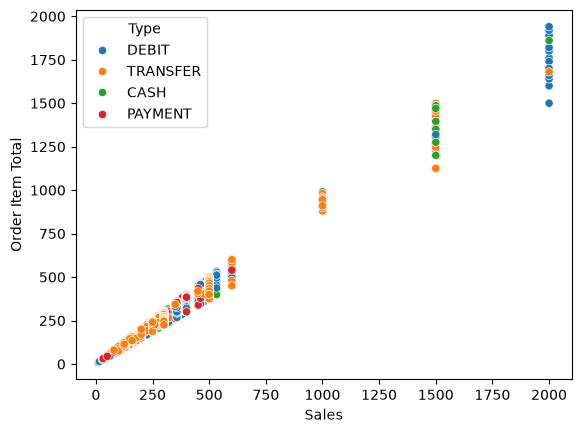

In [44]:
sns.scatterplot(x=df["Sales"], y=df["Order Item Total"], hue=df["Type"])
plt.show()

Sales and order item total have clear positive relation.<br>
In diff payment method the relation is positive.


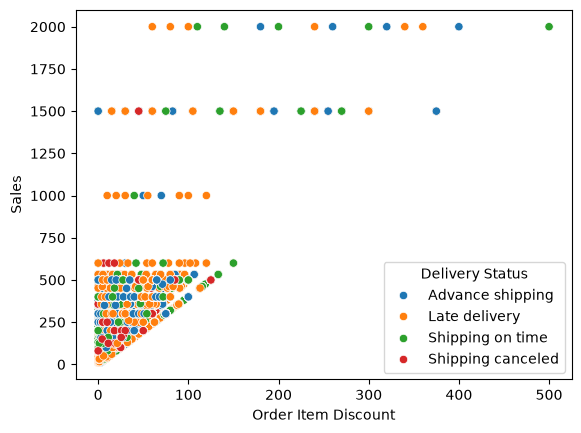

In [45]:
sns.scatterplot(x=df["Order Item Discount"], y=df["Sales"], hue=df["Delivery Status"])
plt.show()

There is a positive relationship between Order Item Discount and Sales.<br>
Different Delivery Status categories are compared using colors.<br>
Higher discount values generally show higher Sales values.

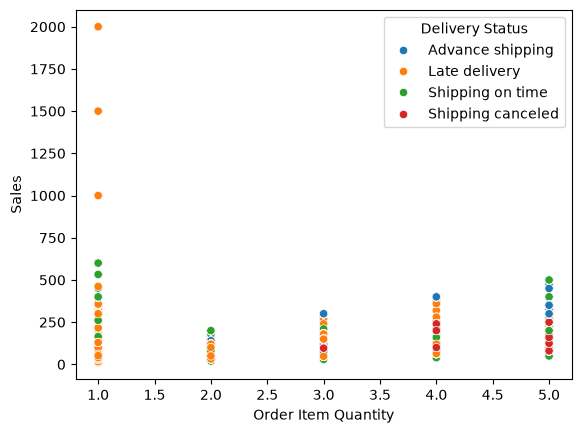

In [46]:
sns.scatterplot(x=df["Order Item Quantity"], y=df["Sales"], hue=df["Delivery Status"])
plt.show()

Sales generally increase as Order Item Quantity increases.<br>
Late delivery has some of the highest Sales values.

### feature engineering

In [47]:
df["Shipping Delay"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

In [48]:
df["Shipping Delay"].value_counts().sort_index()

Shipping Delay
-2    21666
-1    21700
 0    33751
 1    60646
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64

Most orders have positive shipping delay, with 1 day having most common delay(60,646).<br>
Negative values indicate that some orders were shipped earlier than scheduled.

In [49]:
df["Value per Item"] = df["Order Item Total"] / df["Order Item Quantity"]

value per item represents the value of a single item in an order.<br>
it helps compare order values independent of the quantity purchased.

<Axes: >

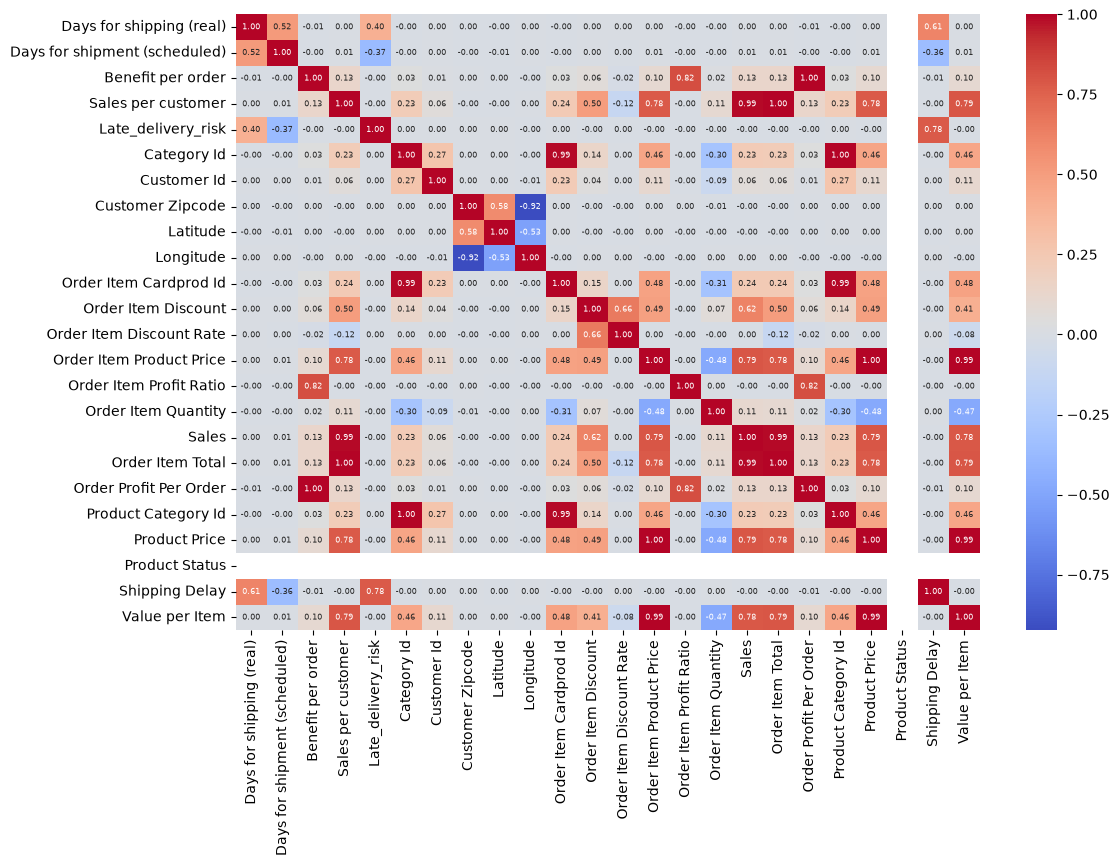

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only = True) , annot =True , fmt = '.2f' , cmap = 'coolwarm' , annot_kws = {'size':6})

### PCA

In [51]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols)

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Latitude',
       'Longitude', 'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Product Category Id',
       'Product Price', 'Product Status', 'Shipping Delay', 'Value per Item'],
      dtype='str')


In [52]:
pca_cols = num_cols.drop([
    "Customer Id",
    "Category Id",
    "Product Category Id",
    "Order Item Cardprod Id",
    "Customer Zipcode",
    "Late_delivery_risk",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Shipping Delay"
])

X_pca = df[pca_cols]
print(X_pca.shape)

(180516, 15)


In [91]:
print(pca_cols)

Index(['Benefit per order', 'Sales per customer', 'Latitude', 'Longitude',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Product Price', 'Product Status',
       'Value per Item'],
      dtype='str')


In PCA I have removed three types of columns Id columns ,zipcode,taget col bcoz they are not suitable for PCA
I have also deleted cols which are directly related to target col bcoz dataleakage is happened when i performed random forest .

In [53]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_scaled = sc.fit_transform(X_pca)

print(X_scaled.shape)

(180516, 15)


now there are 15 numerical cols on which we will perform pca

In [54]:
from sklearn.decomposition import PCA

pca = PCA()
d = pca.fit_transform(X_scaled)
print(d.shape)

(180516, 15)


In [55]:
variance = pca.explained_variance_ratio_
print(variance)

[4.11148814e-01 1.95174184e-01 1.17138427e-01 1.08903622e-01
 1.04040955e-01 3.39194015e-02 1.57647709e-02 9.25727417e-03
 4.54484629e-03 1.07705990e-04 6.47854985e-12 4.26244172e-17
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [56]:
cum_var = variance.cumsum()
print(cum_var)

[0.41114881 0.606323   0.72346142 0.83236505 0.936406   0.9703254
 0.98609017 0.99534745 0.99989229 1.         1.         1.
 1.         1.         1.        ]


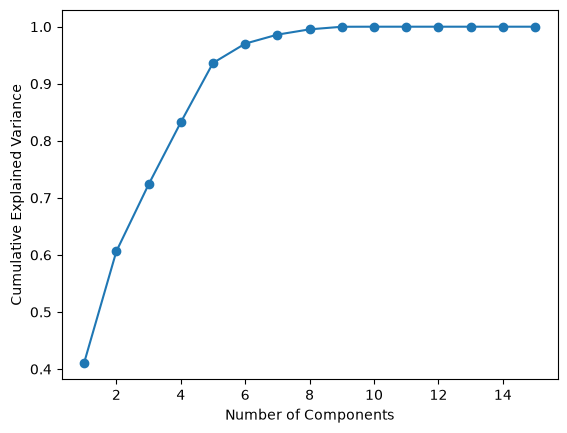

In [57]:
plt.plot(range(1, len(cum_var) +1), cum_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

The first 6 components explain about 97% of the variance.<br>
Including 8 & 9 component about 99 % <br>
after 6 component the graph is almost becoming flat ,the increse is very small.<br>
so 6 components are sufficient for dimentially reduction

In [58]:
newpca = PCA(n_components=6)
m = newpca.fit_transform(X_scaled)

print(m.shape)

(180516, 6)


In [59]:
new_var = newpca.explained_variance_ratio_
print(new_var)

[0.41114881 0.19517418 0.11713843 0.10890362 0.10404095 0.0339194 ]


In [60]:
total_var = new_var.cumsum()
print(total_var)

[0.41114881 0.606323   0.72346142 0.83236505 0.936406   0.9703254 ]


6 components explain about 97% of the total variance.<br>
PCA reduced the dimensions from 15 to 6 while retaining most of the information.

### ENSEMBLE LEARNING

In [61]:
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)

Index(['Type', 'Delivery Status', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Segment', 'Customer State',
       'Department Name', 'Market', 'Order City', 'Order Country',
       'Order Region', 'Order State', 'Order Status', 'Product Name',
       'Shipping Mode'],
      dtype='str')


C:\Users\vartika singh\AppData\Local\Temp\ipykernel_11700\489604010.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [62]:
cols = [
    "Category Name",
    "Customer Country",
    "Customer City",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Region",
    "Order Country",
    "Order Status",
    "Shipping Mode"
]

print(cols)

['Category Name', 'Customer Country', 'Customer City', 'Customer Segment', 'Department Name', 'Market', 'Order Region', 'Order Country', 'Order Status', 'Shipping Mode']


cols to be choosen for train test split

### ENCODING

In [63]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_data = enc.fit_transform(df[cols])
print(cat_data.shape)

(180516, 833)


encoding of categorical cols

In [64]:
x = np.hstack((m, cat_data))
print(x.shape)

(180516, 839)


combining the categorical cols and the num pca cols for train test split 

### SELECTING INPUT AND TARGET COLS

In [65]:
y = df["Late_delivery_risk"]
print(y.value_counts())

Late_delivery_risk
1    98976
0    81540
Name: count, dtype: int64


late delivery risk is the target col

### TRAIN TEST SPLIT

In [66]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(x_train.shape)
print(x_test.shape)

(144412, 839)
(36104, 839)


In [69]:
import sys

print(sys.executable)
print(sys.version)

c:\ProgramData\anaconda3\python.exe
3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]


### RANDOM FOREST

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50,random_state=42)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [71]:
y_pred = rf.predict(x_test)
print(y_pred[:10])

[0 0 1 0 0 1 0 0 0 1]


In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acr = accuracy_score(y_test, y_pred)
pr = precision_score(y_test, y_pred)
rr = recall_score(y_test, y_pred)
fr = f1_score(y_test, y_pred)

print("accuracy :", acr)
print("precision:", pr)
print("recall   :", rr)
print("F1 Score :", fr)

accuracy : 0.7686405938400177
precision: 0.8425432557025684
recall   : 0.7109011921600323
F1 Score : 0.7711444149154771


The random forest achieved accuracy about 76.86%<br>
Precision is 84.4%<br>
recall is 71.09%<br>
F1 score is 77.11%

In [74]:
imp = rf.feature_importances_
print(imp[:6])

[0.05453623 0.05527591 0.05487717 0.05697984 0.05514864 0.05882782]


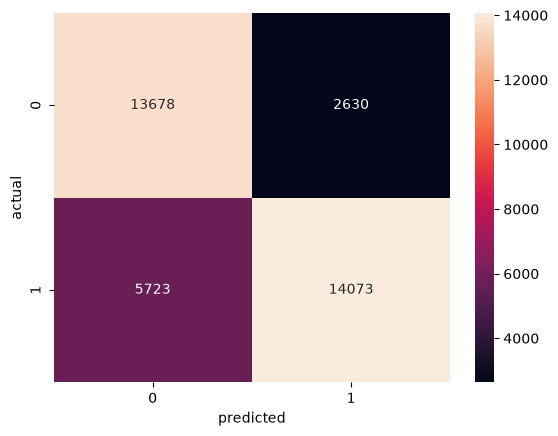

In [75]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

### ADABOOST

In [76]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(n_estimators=50,random_state=42)
ab.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.31,0.4 ,0.43,...,0.49,0.49,0.49]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.8 ,0.41,0.3 ,...,0.06,0.06,0.06]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](839,)","[0. ,0. ,0. ,...,0.05,0. ,0.12]"


In [77]:
y_pred = ab.predict(x_test)
print(y_pred[:10])

[0 0 1 0 0 1 0 0 0 0]


In [78]:
aca = accuracy_score(y_test, y_pred)
pa = precision_score(y_test, y_pred)
ra = recall_score(y_test, y_pred)
fa = f1_score(y_test, y_pred)

print("Accuracy :", aca)
print("Precision:", pa)
print("Recall   :", ra)
print("F1 Score :", fa)

Accuracy : 0.7013073343673831
Precision: 0.8157230941704036
Recall   : 0.5880986057789452
F1 Score : 0.6834566161794059


The adaboost achieved accuracy about 70.13%<br>
Precision is 81.5%<br>
recall is 58.8%<br>
F1 score is 68.34%

In [79]:
imp = ab.feature_importances_
print(imp[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


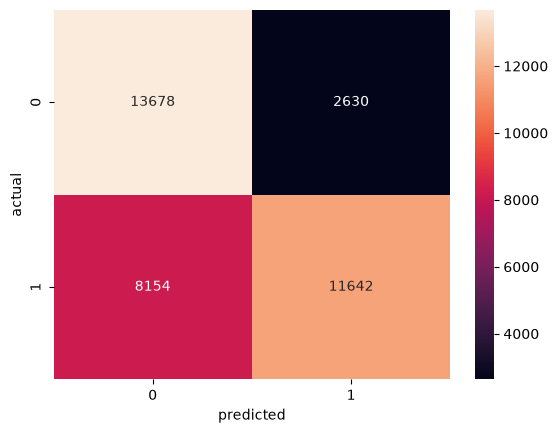

In [80]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

### XGBOOST

In [81]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100,random_state=42)
xgb.fit(x_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [83]:
y_pred_xgb = xgb.predict(x_test)

print(y_pred_xgb[:10])

[0 0 1 0 0 1 0 0 0 0]


In [84]:
acx = accuracy_score(y_test, y_pred_xgb)
px = precision_score(y_test, y_pred_xgb)
rx = recall_score(y_test, y_pred_xgb)
fx = f1_score(y_test, y_pred_xgb)

print("Accuracy :", acx)
print("Precision:", px)
print("Recall   :", rx)
print("F1 Score :", fx)

Accuracy : 0.7220806558830046
Precision: 0.8653443113772455
Recall   : 0.5840068700747626
F1 Score : 0.697370008444927


In [85]:
imp = xgb.feature_importances_
print(imp[:10])

[0.00063934 0.00069307 0.0006342  0.00114556 0.00059652 0.00138932
 0.         0.         0.         0.        ]


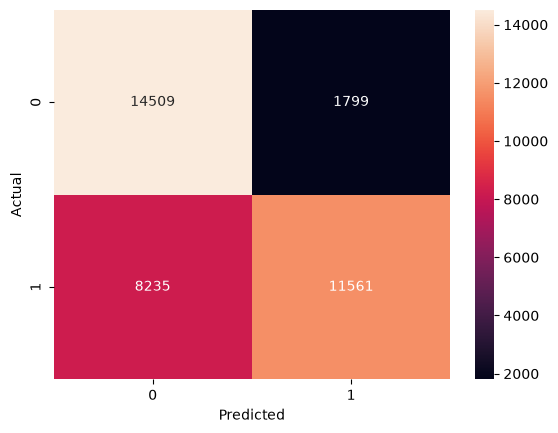

In [86]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### COMPARISION

In [87]:
comp = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Accuracy": [acr, aca, acx],
    "Precision": [pr, pa, px],
    "Recall": [rr, ra, rx],
    "F1 Score": [fr, fa, fx]
})

print(comp)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.768641   0.842543  0.710901  0.771144
1       AdaBoost  0.701307   0.815723  0.588099  0.683457
2        XGBoost  0.722081   0.865344  0.584007  0.697370


Random Forest achieved the highest accuracy(76.8%) & F1-score(77.11%) & racall(71.09)<br>
XGboost has highest precision 86.53%<br>


### JOBLIB

In [88]:
import joblib 
joblib.dump(xgb,"best_model.pkl")
print("model saved xgb")

model saved xgb


In [89]:
m = joblib.load("best_model.pkl")
y_new = m.predict(x_test)

print(y_new[:10])

[0 0 1 0 0 1 0 0 0 0]


In [90]:
import joblib

joblib.dump(xgb, "best_model.pkl")
joblib.dump(sc, "scaler.pkl")
joblib.dump(newpca, "pca.pkl")
joblib.dump(enc, "encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


In [92]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
